# NB12 — TEstadia por Vessel Segment · ANTAQ 2025

**Objetivo:** Avaliar se existe gradiente claro de TEstadia com aumento de tamanho do navio,  
desagregando por porto principal e por terminal em Santos.

**Datasets:** 2025_Atracacao · 2025_Tempos_Atracacao · Vessels_Master_Enriched  
**Filtro:** Longo Curso apenas (exclui Cabotagem, Interior, Apoio Marítimo, Apoio Portuário, Offshore, Marinha)  
**Data de execução:** 2025

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────────────────────
DATA_OPER  = '../data/02_Operacoes/'
DATA_IND   = '../data/03_Indicadores/'
FIG_DIR    = '../outputs/figures/'
CSV_DIR    = '../outputs/processed_data/'
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(CSV_DIR, exist_ok=True)

# ── Segment order (ascending size) ─────────────────────────────────────────
SEGMENT_ORDER = [
    'Feeder Max (1k-3k TEU)',
    'Sub-Panamax (3k-8k TEU)',
    'Post-Panamax (8k-12k TEU)',
    'New Panamax (12k-18k TEU)',
    'Ultra Large (> 18k TEU)',
]
SEG_SHORT = {
    'Feeder Max (1k-3k TEU)':     'Feeder Max',
    'Sub-Panamax (3k-8k TEU)':    'Sub-Panamax',
    'Post-Panamax (8k-12k TEU)':  'Post-Panamax',
    'New Panamax (12k-18k TEU)':  'New Panamax',
    'Ultra Large (> 18k TEU)':    'ULCV',
}
SEG_COLORS = {
    'Feeder Max (1k-3k TEU)':     '#4878CF',
    'Sub-Panamax (3k-8k TEU)':    '#6ACC65',
    'Post-Panamax (8k-12k TEU)':  '#D65F5F',
    'New Panamax (12k-18k TEU)':  '#B47CC7',
    'Ultra Large (> 18k TEU)':    '#C4AD66',
}
SEG_COLOR_LIST = [SEG_COLORS[s] for s in SEGMENT_ORDER]

# ── Portos principais a analisar ────────────────────────────────────────────
PORTOS_PRINCIPAIS = ['Santos', 'Paranaguá', 'Rio de Janeiro',
                     'Suape', 'Pecém', 'Rio Grande', 'Itaguaí']

# ── Tempo cols ─────────────────────────────────────────────────────────────
TIME_COLS = ['TEsperaAtracacao', 'TEsperaInicioOp', 'TOperacao',
             'TEsperaDesatracacao', 'TAtracado', 'TEstadia']

plt.rcParams.update({'figure.dpi': 150, 'font.size': 10,
                     'axes.spines.top': False, 'axes.spines.right': False})
print('Setup OK')

Setup OK


---
## Passo 0 — Carga e Pré-processamento

In [2]:
# ── 0.1 Atracação ──────────────────────────────────────────────────────────
atr_raw = pd.read_csv(
    DATA_OPER + '2025_Atracacao.csv',
    encoding='utf-8-sig', sep=';', low_memory=False
)
NAV_COL = [c for c in atr_raw.columns if 'Navega' in c][0]
print(f'Coluna navegação: {NAV_COL!r}')
print(f'Total atracações raw: {len(atr_raw):,}')
print('Tipos de navegação:')
print(atr_raw[NAV_COL].value_counts())

Coluna navegação: 'Tipo de Navegação da Atracação'
Total atracações raw: 116,098
Tipos de navegação:
Tipo de Navegação da Atracação
Interior           54127
Longo Curso        22746
Cabotagem          21183
Apoio Marítimo     11798
Apoio Portuário     6238
Name: count, dtype: int64


In [3]:
# ── 0.2 Filtro Longo Curso ─────────────────────────────────────────────────
atr = atr_raw[atr_raw[NAV_COL] == 'Longo Curso'].copy()
n_lc = len(atr)
print(f'Atracações Longo Curso: {n_lc:,}')

Atracações Longo Curso: 22,746


In [4]:
# ── 0.3 Tempos ─────────────────────────────────────────────────────────────
tem_raw = pd.read_csv(
    DATA_IND + '2025_Tempos_Atracacao.csv',
    encoding='utf-8-sig', sep=';'
)
tem = tem_raw.copy()
for col in TIME_COLS:
    tem[col] = pd.to_numeric(
        tem[col].astype(str).str.replace(',', '.', regex=False),
        errors='coerce'
    )
print(f'Tempos carregados: {len(tem):,} registos')
print(tem[TIME_COLS].describe().round(2))

Tempos carregados: 116,098 registos
       TEsperaAtracacao  TEsperaInicioOp  TOperacao  TEsperaDesatracacao  \
count         111876.00        106975.00  106901.00            108184.00   
mean              33.72             3.27      18.27                 3.05   
std               88.24            21.26      31.84                 9.16   
min                0.02             0.02       0.02                 0.02   
25%                0.17             0.08       2.23                 0.17   
50%                1.00             0.40       6.75                 0.92   
75%               25.00             1.92      19.03                 2.83   
max             1832.87          2036.92     893.00               485.98   

       TAtracado   TEstadia  
count  113926.00  113853.00  
mean       24.91      59.16  
std        42.18     106.33  
min         0.02       0.03  
25%         3.83       6.58  
50%        10.83      19.67  
75%        27.40      63.15  
max      2045.93    2046.02  


In [5]:
# ── 0.4 Outliers P99 por terminal ─────────────────────────────────────────
# Join rápido para identificar terminal
tem_with_terminal = tem.merge(
    atr[['IDAtracacao', 'Terminal', 'Porto Atracação']],
    on='IDAtracacao', how='inner'
)

p99_by_terminal = (
    tem_with_terminal.groupby('Terminal')['TEstadia']
    .quantile(0.99)
    .reset_index()
    .rename(columns={'TEstadia': 'P99_TEstadia'})
)
tem_with_terminal = tem_with_terminal.merge(p99_by_terminal, on='Terminal', how='left')
outliers_p99 = tem_with_terminal[tem_with_terminal['TEstadia'] > tem_with_terminal['P99_TEstadia']].copy()

print(f'Registos TEstadia > P99 por terminal: {len(outliers_p99):,}')
print(f'  → {len(outliers_p99)/len(tem_with_terminal)*100:.2f}% do total LC')
print('Outliers por terminal (top 10):')
print(outliers_p99.groupby('Terminal')['TEstadia'].agg(['count','max']).sort_values('max', ascending=False).head(10))

Registos TEstadia > P99 por terminal: 318
  → 1.40% do total LC
Outliers por terminal (top 10):
                                                    count          max
Terminal                                                              
Corredor de Fertilizantes                               2  1826.750000
Corredor de Exportação Leste                            4  1653.083333
Terminal de Praia Mole                                  2  1536.250000
CAIS PÚBLICO                                            7  1529.750000
PIER DA FOSPAR                                          1  1415.450000
Terminal Integrador Portuário Luiz Antonio Mesq...      4  1175.883333
Corredor de Exportação Oeste                            1  1113.366667
Terminal Portuário do Pecém                             4  1070.500000
Cais Público                                           12  1046.666667
Terminal Marítimo de Ponta da Madeira                   7  1040.566667


In [6]:
# ── 0.5 Vessels_Master_Enriched ───────────────────────────────────────────
vme = pd.read_csv(
    DATA_OPER + 'Vessels_Master_Enriched.csv',
    encoding='utf-8-sig'
)
vme['imo_key'] = vme['NÚMERO IMO'].astype('Int64')
print(f'Vessels_Master_Enriched: {len(vme):,} navios')
print('vessel_segment:')
print(vme['vessel_segment'].value_counts())

Vessels_Master_Enriched: 1,378 navios
vessel_segment:
vessel_segment
Sub-Panamax (3k-8k TEU)      536
New Panamax (12k-18k TEU)    285
Post-Panamax (8k-12k TEU)    269
Feeder Max (1k-3k TEU)       164
Ultra Large (> 18k TEU)      124
Name: count, dtype: int64


In [7]:
# ── 0.6 Join Atracação × Tempos × Vessels_Master ──────────────────────────
# Preparar IMO key em atr
atr['imo_key'] = pd.to_numeric(atr['Nº do IMO'], errors='coerce').astype('Int64')
imo_zero_mask = atr['imo_key'].isna() | (atr['imo_key'] == 0)
atr.loc[imo_zero_mask, 'imo_key'] = pd.NA

# Join Atracação × Vessels_Master
atr = atr.merge(
    vme[['imo_key', 'vessel_segment', 'SHIPPING LINE', 'CAPACIDADE (TEU)']],
    on='imo_key', how='left'
)

# Flag segment_identified
atr['segment_identified'] = atr['vessel_segment'].notna()
atr['vessel_segment'] = atr['vessel_segment'].fillna('Indeterminado')

pct_id = atr['segment_identified'].mean() * 100
print(f'Atracações LC com vessel_segment identificado: {atr["segment_identified"].sum():,} de {n_lc:,} ({pct_id:.1f}%)')
print()
print('Distribuição vessel_segment:')
print(atr['vessel_segment'].value_counts())

# Join Atracação × Tempos
df = atr.merge(tem[['IDAtracacao'] + TIME_COLS], on='IDAtracacao', how='inner')
print(f'\nDataset final (LC + Tempos): {len(df):,} registos')

Atracações LC com vessel_segment identificado: 705 de 22,746 (3.1%)

Distribuição vessel_segment:
vessel_segment
Indeterminado                22041
Sub-Panamax (3k-8k TEU)        271
Post-Panamax (8k-12k TEU)      216
New Panamax (12k-18k TEU)      114
Feeder Max (1k-3k TEU)          92
Ultra Large (> 18k TEU)         12
Name: count, dtype: int64

Dataset final (LC + Tempos): 22,746 registos


---
## Parte 1 — KPIs por Vessel Segment

In [8]:
# ── Tabela KPIs por segment ────────────────────────────────────────────────
df_seg = df[df['vessel_segment'] != 'Indeterminado'].copy()

kpi_rows = []
for seg in SEGMENT_ORDER:
    sub = df_seg[df_seg['vessel_segment'] == seg]
    if len(sub) == 0:
        continue
    kpi_rows.append({
        'Segment': SEG_SHORT[seg],
        'N_Atracacoes': len(sub),
        'TEstadia_P25':  sub['TEstadia'].quantile(0.25),
        'TEstadia_Med':  sub['TEstadia'].median(),
        'TEstadia_P75':  sub['TEstadia'].quantile(0.75),
        'TEstadia_IQR':  sub['TEstadia'].quantile(0.75) - sub['TEstadia'].quantile(0.25),
        'TEspera_Med':   sub['TEsperaAtracacao'].median(),
        'TOperacao_Med': sub['TOperacao'].median(),
        'TAtracado_Med': sub['TAtracado'].median(),
    })

kpi_seg = pd.DataFrame(kpi_rows)
pd.options.display.float_format = '{:.1f}'.format
print('KPIs por Vessel Segment (horas):')
print(kpi_seg.to_string(index=False))

KPIs por Vessel Segment (horas):
     Segment  N_Atracacoes  TEstadia_P25  TEstadia_Med  TEstadia_P75  TEstadia_IQR  TEspera_Med  TOperacao_Med  TAtracado_Med
  Feeder Max            92          42.6          85.7         152.0         109.5          4.5           38.1           48.0
 Sub-Panamax           271          28.9          45.4          73.3          44.4         10.9           19.0           24.5
Post-Panamax           216          24.2          37.3          64.9          40.7         10.3           18.1           22.7
 New Panamax           114          25.6          53.0         105.8          80.2         17.4           24.5           27.9
        ULCV            12          46.6          60.3          77.7          31.1         38.5           19.8           24.1


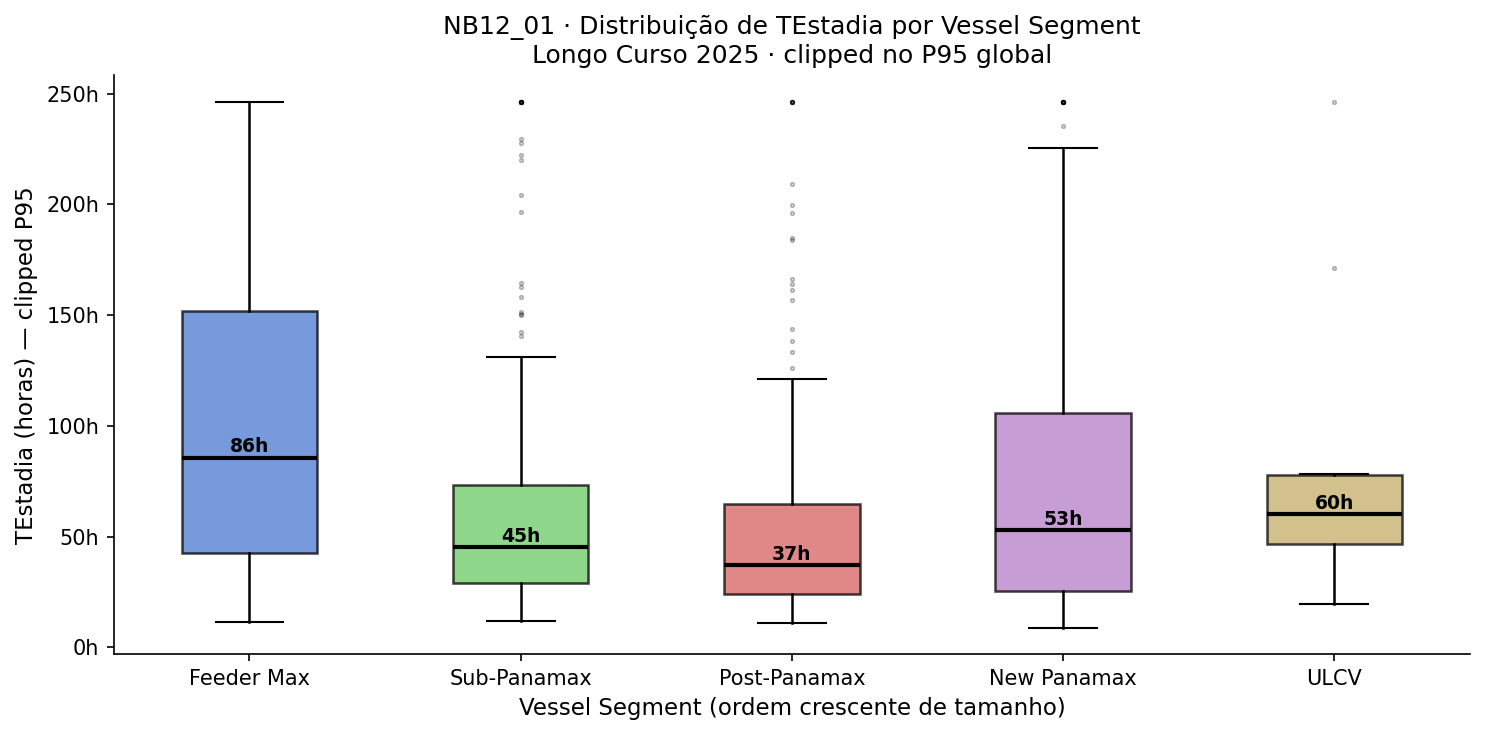

Salvo: nb12_01_boxplot_testadia_segment.png


In [9]:
# ── Figura nb12_01: Box plots TEstadia por segment ─────────────────────────
seg_order_short = [SEG_SHORT[s] for s in SEGMENT_ORDER if s in df_seg['vessel_segment'].unique()]
df_plot = df_seg.copy()
df_plot['seg_short'] = df_plot['vessel_segment'].map(SEG_SHORT)

# Clip a P95 para legibilidade
p95_global = df_plot['TEstadia'].quantile(0.95)
df_plot['TEstadia_clip'] = df_plot['TEstadia'].clip(upper=p95_global)

fig, ax = plt.subplots(figsize=(10, 5))
data_bp = [df_plot[df_plot['seg_short'] == s]['TEstadia_clip'].dropna().values
           for s in seg_order_short]
bp = ax.boxplot(data_bp, labels=seg_order_short, patch_artist=True,
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(linewidth=1.2),
                boxprops=dict(linewidth=1.2),
                flierprops=dict(marker='.', markersize=3, alpha=0.3))
for patch, seg in zip(bp['boxes'], SEGMENT_ORDER):
    patch.set_facecolor(SEG_COLORS[seg])
    patch.set_alpha(0.75)

# Anotar mediana
for idx, seg in enumerate(seg_order_short):
    med_val = df_plot[df_plot['seg_short'] == seg]['TEstadia'].median()
    ax.text(idx + 1, med_val + 0.5, f'{med_val:.0f}h', ha='center', va='bottom',
            fontsize=9, fontweight='bold', color='black')

ax.set_xlabel('Vessel Segment (ordem crescente de tamanho)', fontsize=11)
ax.set_ylabel('TEstadia (horas) — clipped P95', fontsize=11)
ax.set_title('NB12_01 · Distribuição de TEstadia por Vessel Segment\n'
             'Longo Curso 2025 · clipped no P95 global', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0fh'))
plt.tight_layout()
plt.savefig(FIG_DIR + 'nb12_01_boxplot_testadia_segment.png', dpi=150)
plt.show()
print('Salvo: nb12_01_boxplot_testadia_segment.png')

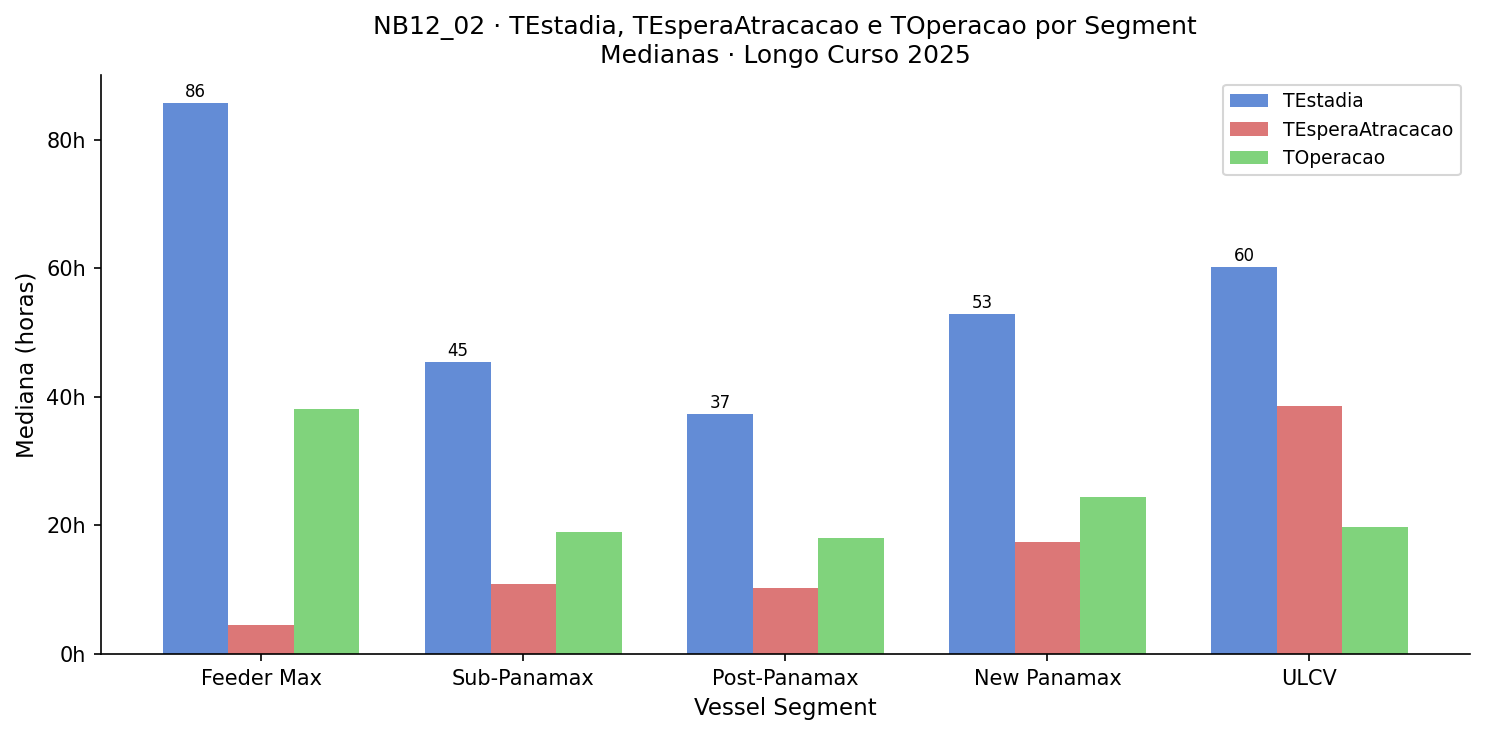

Salvo: nb12_02_kpis_por_segment.png


In [10]:
# ── Figura nb12_02: Mediana TEstadia + TEspera + TOperação por segment ─────
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(seg_order_short))
w = 0.25

med_est = [kpi_seg[kpi_seg['Segment'] == s]['TEstadia_Med'].values[0] for s in seg_order_short]
med_esp = [kpi_seg[kpi_seg['Segment'] == s]['TEspera_Med'].values[0] for s in seg_order_short]
med_op  = [kpi_seg[kpi_seg['Segment'] == s]['TOperacao_Med'].values[0] for s in seg_order_short]

ax.bar(x - w, med_est, w, label='TEstadia', color='#4878CF', alpha=0.85)
ax.bar(x,     med_esp, w, label='TEsperaAtracacao', color='#D65F5F', alpha=0.85)
ax.bar(x + w, med_op,  w, label='TOperacao', color='#6ACC65', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(seg_order_short)
ax.set_xlabel('Vessel Segment', fontsize=11)
ax.set_ylabel('Mediana (horas)', fontsize=11)
ax.set_title('NB12_02 · TEstadia, TEsperaAtracacao e TOperacao por Segment\n'
             'Medianas · Longo Curso 2025', fontsize=12)
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0fh'))

# Anotar TEstadia
for idx, val in enumerate(med_est):
    ax.text(x[idx] - w, val + 0.3, f'{val:.0f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR + 'nb12_02_kpis_por_segment.png', dpi=150)
plt.show()
print('Salvo: nb12_02_kpis_por_segment.png')

In [11]:
# ── Resposta Parte 1 ───────────────────────────────────────────────────────
print('=== GRADIENTE TEstadia × Tamanho do Navio ===')
for _, row in kpi_seg.iterrows():
    print(f"  {row['Segment']:20s}  Mediana={row['TEstadia_Med']:.0f}h  "
          f"IQR={row['TEstadia_IQR']:.0f}h  TEspera={row['TEspera_Med']:.0f}h  "
          f"TOperação={row['TOperacao_Med']:.0f}h  N={int(row['N_Atracacoes']):,}")

=== GRADIENTE TEstadia × Tamanho do Navio ===
  Feeder Max            Mediana=86h  IQR=109h  TEspera=4h  TOperação=38h  N=92
  Sub-Panamax           Mediana=45h  IQR=44h  TEspera=11h  TOperação=19h  N=271
  Post-Panamax          Mediana=37h  IQR=41h  TEspera=10h  TOperação=18h  N=216
  New Panamax           Mediana=53h  IQR=80h  TEspera=17h  TOperação=24h  N=114
  ULCV                  Mediana=60h  IQR=31h  TEspera=39h  TOperação=20h  N=12


---
## Parte 2 — TEstadia por Porto × Vessel Segment (Heatmap)

In [12]:
# ── Filtrar portos principais + segment identificado ─────────────────────
df_porto = df_seg[df_seg['Porto Atracação'].isin(PORTOS_PRINCIPAIS)].copy()

# Células com < 20 obs — listar separadamente
cell_counts = (
    df_porto.groupby(['Porto Atracação', 'vessel_segment'])
    .size()
    .reset_index(name='N')
)
cells_excluidas = cell_counts[cell_counts['N'] < 20].copy()
print(f'Células porto×segment com <20 obs (excluídas do heatmap): {len(cells_excluidas)}')
if len(cells_excluidas) > 0:
    print(cells_excluidas.to_string(index=False))

Células porto×segment com <20 obs (excluídas do heatmap): 18
Porto Atracação            vessel_segment  N
        Itaguaí New Panamax (12k-18k TEU)  1
        Itaguaí Post-Panamax (8k-12k TEU)  2
        Itaguaí   Sub-Panamax (3k-8k TEU)  3
      Paranaguá    Feeder Max (1k-3k TEU)  4
      Paranaguá New Panamax (12k-18k TEU)  9
      Paranaguá   Ultra Large (> 18k TEU)  1
     Rio Grande    Feeder Max (1k-3k TEU)  1
     Rio Grande Post-Panamax (8k-12k TEU) 10
     Rio Grande   Sub-Panamax (3k-8k TEU)  3
 Rio de Janeiro    Feeder Max (1k-3k TEU)  9
 Rio de Janeiro New Panamax (12k-18k TEU) 16
 Rio de Janeiro   Ultra Large (> 18k TEU)  2
         Santos    Feeder Max (1k-3k TEU) 13
         Santos   Ultra Large (> 18k TEU)  3
          Suape    Feeder Max (1k-3k TEU)  2
          Suape New Panamax (12k-18k TEU)  1
          Suape Post-Panamax (8k-12k TEU) 13
          Suape   Sub-Panamax (3k-8k TEU)  2


In [13]:
# ── Pivot: mediana TEstadia (só células >= 20 obs) ─────────────────────────
valid_cells = cell_counts[cell_counts['N'] >= 20].set_index(['Porto Atracação', 'vessel_segment'])

# Calcular medianas
med_matrix = (
    df_porto.groupby(['Porto Atracação', 'vessel_segment'])['TEstadia']
    .median()
    .reset_index()
    .rename(columns={'TEstadia': 'TEstadia_Med'})
)

# Marcar células insuficientes como NaN
med_matrix['cell_key'] = list(zip(med_matrix['Porto Atracação'], med_matrix['vessel_segment']))
valid_keys = set(zip(valid_cells.index.get_level_values(0), valid_cells.index.get_level_values(1)))
med_matrix['TEstadia_Med'] = med_matrix.apply(
    lambda r: r['TEstadia_Med'] if r['cell_key'] in valid_keys else np.nan, axis=1
)

# Pivot
seg_cols = [s for s in SEGMENT_ORDER if s in med_matrix['vessel_segment'].unique()]
pivot = med_matrix.pivot(index='Porto Atracação', columns='vessel_segment', values='TEstadia_Med')
# Reorder columns
pivot = pivot.reindex(columns=[s for s in SEGMENT_ORDER if s in pivot.columns])
pivot.columns = [SEG_SHORT[c] for c in pivot.columns]

# Reorder rows: Santos first
porto_order = [p for p in PORTOS_PRINCIPAIS if p in pivot.index]
pivot = pivot.reindex(porto_order)

print('Heatmap pivot (TEstadia mediana):')
print(pivot.round(0).to_string())

Heatmap pivot (TEstadia mediana):
                 Feeder Max  Sub-Panamax  Post-Panamax  New Panamax  ULCV
Porto Atracação                                                          
Santos                  NaN         41.0          53.0         68.0   NaN
Paranaguá               NaN         44.0          36.0          NaN   NaN
Rio de Janeiro          NaN         16.0          24.0          NaN   NaN
Suape                   NaN          NaN           NaN          NaN   NaN
Rio Grande              NaN          NaN           NaN          NaN   NaN
Itaguaí                 NaN          NaN           NaN          NaN   NaN


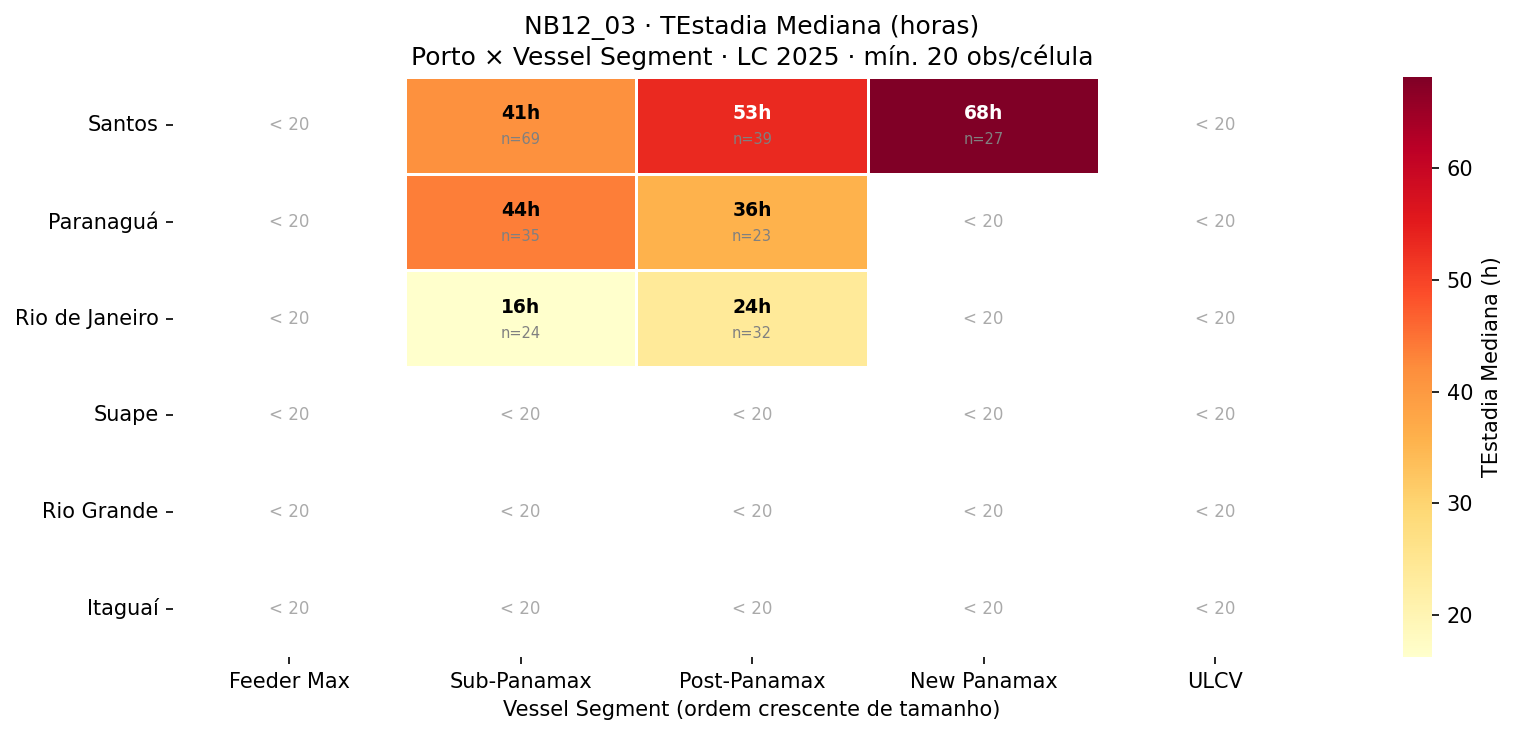

Salvo: nb12_03_heatmap_porto_segment.png


In [14]:
# ── Figura nb12_03: Heatmap porto × segment ────────────────────────────────
# Adicionar contagem de observações
count_pivot = (
    df_porto.groupby(['Porto Atracação', 'vessel_segment'])
    .size()
    .reset_index(name='N')
    .pivot(index='Porto Atracação', columns='vessel_segment', values='N')
    .reindex(index=porto_order, columns=[s for s in SEGMENT_ORDER if s in df_porto['vessel_segment'].unique()])
)
count_pivot.columns = [SEG_SHORT[c] for c in count_pivot.columns]

fig, ax = plt.subplots(figsize=(11, 5))
mask = pivot.isna()

sns.heatmap(
    pivot, annot=False, fmt='.0f', cmap='YlOrRd',
    mask=mask, linewidths=0.5, linecolor='white',
    ax=ax, cbar_kws={'label': 'TEstadia Mediana (h)'}
)

# Anotações manuais com valor + N
for row_idx, porto in enumerate(pivot.index):
    for col_idx, seg_s in enumerate(pivot.columns):
        val = pivot.iloc[row_idx, col_idx]
        cnt = count_pivot.iloc[row_idx, col_idx] if seg_s in count_pivot.columns else np.nan
        if not np.isnan(val):
            ax.text(col_idx + 0.5, row_idx + 0.38, f'{val:.0f}h',
                    ha='center', va='center', fontsize=9, fontweight='bold',
                    color='black' if val < pivot.max().max() * 0.7 else 'white')
            if not np.isnan(cnt):
                ax.text(col_idx + 0.5, row_idx + 0.65, f'n={int(cnt)}',
                        ha='center', va='center', fontsize=7, color='gray')
        else:
            ax.text(col_idx + 0.5, row_idx + 0.5, '< 20',
                    ha='center', va='center', fontsize=8, color='#aaaaaa')

ax.set_title('NB12_03 · TEstadia Mediana (horas)\nPorto × Vessel Segment · LC 2025 · mín. 20 obs/célula',
             fontsize=12)
ax.set_xlabel('Vessel Segment (ordem crescente de tamanho)', fontsize=10)
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(FIG_DIR + 'nb12_03_heatmap_porto_segment.png', dpi=150)
plt.show()
print('Salvo: nb12_03_heatmap_porto_segment.png')

---
## Parte 3 — Desagregação por Terminal em Santos

In [15]:
# ── Santos LC, terminais com >= 50 atracações LC ───────────────────────────
df_santos = df_seg[df_seg['Porto Atracação'] == 'Santos'].copy()

terminal_counts = df_santos['Terminal'].value_counts()
santos_terminais_50 = terminal_counts[terminal_counts >= 50].index.tolist()

print(f'Santos LC atracações (segment identificado): {len(df_santos):,}')
print(f'Terminais com >= 50 atracações LC: {len(santos_terminais_50)}')
for t in santos_terminais_50:
    print(f'  {terminal_counts[t]:>4}  {t}')

Santos LC atracações (segment identificado): 151
Terminais com >= 50 atracações LC: 2
    62  Cais da BTP (SSZ 41) - Privativo
    61  Cais da Santos Brasil (SSZ 16) - Privativo


In [16]:
# ── Tabela Santos: TEstadia + TEspera por terminal × segment ──────────────
df_santos_top = df_santos[df_santos['Terminal'].isin(santos_terminais_50)].copy()

santos_rows = []
for term in santos_terminais_50:
    sub_t = df_santos_top[df_santos_top['Terminal'] == term]
    row_dict = {'Terminal': term, 'N_Total': len(sub_t)}
    for seg in SEGMENT_ORDER:
        sub_ts = sub_t[sub_t['vessel_segment'] == seg]
        label = SEG_SHORT[seg]
        if len(sub_ts) >= 20:
            row_dict[f'TEstadia_{label}'] = round(sub_ts['TEstadia'].median(), 1)
            row_dict[f'TEspera_{label}']  = round(sub_ts['TEsperaAtracacao'].median(), 1)
            row_dict[f'N_{label}']        = len(sub_ts)
        else:
            row_dict[f'TEstadia_{label}'] = np.nan
            row_dict[f'TEspera_{label}']  = np.nan
            row_dict[f'N_{label}']        = len(sub_ts)
    santos_rows.append(row_dict)

santos_table = pd.DataFrame(santos_rows).sort_values('N_Total', ascending=False)

# Exibir: só colunas TEstadia + N
estadia_cols = ['Terminal', 'N_Total'] + [f'TEstadia_{SEG_SHORT[s]}' for s in SEGMENT_ORDER]
print('TEstadia Mediana por Terminal × Segment em Santos (NaN = <20 obs):')
print(santos_table[estadia_cols].to_string(index=False))

TEstadia Mediana por Terminal × Segment em Santos (NaN = <20 obs):
                                  Terminal  N_Total  TEstadia_Feeder Max  TEstadia_Sub-Panamax  TEstadia_Post-Panamax  TEstadia_New Panamax  TEstadia_ULCV
          Cais da BTP (SSZ 41) - Privativo       62                  NaN                  55.4                    NaN                   NaN            NaN
Cais da Santos Brasil (SSZ 16) - Privativo       61                  NaN                  39.1                    NaN                   NaN            NaN


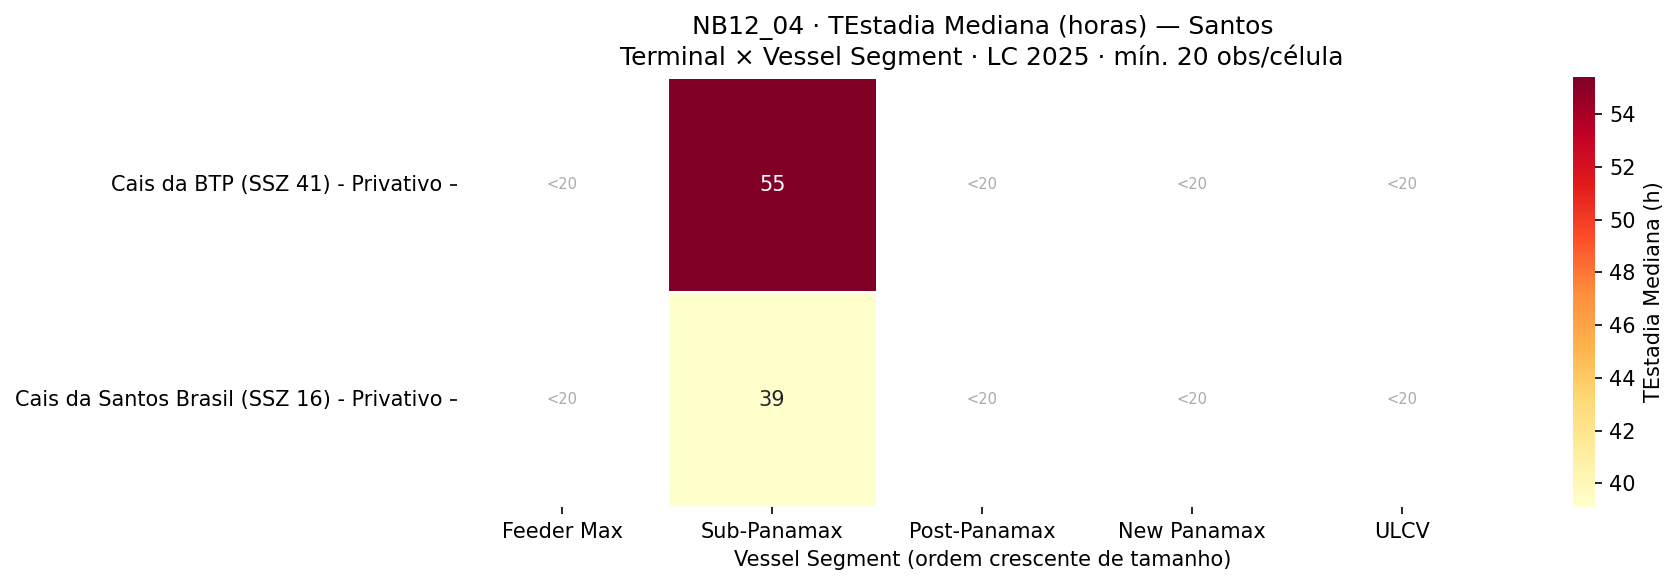

Salvo: nb12_04_heatmap_santos_terminal_segment.png


In [17]:
# ── Figura nb12_04: Heatmap Santos terminal × segment ─────────────────────
# Pivotar TEstadia
seg_cols_short = [SEG_SHORT[s] for s in SEGMENT_ORDER]
heat_data = santos_table.set_index('Terminal')[[f'TEstadia_{s}' for s in seg_cols_short]].copy()
heat_data.columns = seg_cols_short

fig, ax = plt.subplots(figsize=(12, max(4, len(santos_terminais_50) * 0.55)))
mask_s = heat_data.isna()

sns.heatmap(
    heat_data, annot=True, fmt='.0f', cmap='YlOrRd',
    mask=mask_s, linewidths=0.5, linecolor='white',
    ax=ax, cbar_kws={'label': 'TEstadia Mediana (h)'}
)

# Marcar NaN cells
for row_idx in range(len(heat_data)):
    for col_idx in range(len(heat_data.columns)):
        if mask_s.iloc[row_idx, col_idx]:
            ax.text(col_idx + 0.5, row_idx + 0.5, '<20',
                    ha='center', va='center', fontsize=7, color='#aaaaaa')

ax.set_title('NB12_04 · TEstadia Mediana (horas) — Santos\nTerminal × Vessel Segment · LC 2025 · mín. 20 obs/célula',
             fontsize=12)
ax.set_xlabel('Vessel Segment (ordem crescente de tamanho)', fontsize=10)
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(FIG_DIR + 'nb12_04_heatmap_santos_terminal_segment.png', dpi=150)
plt.show()
print('Salvo: nb12_04_heatmap_santos_terminal_segment.png')

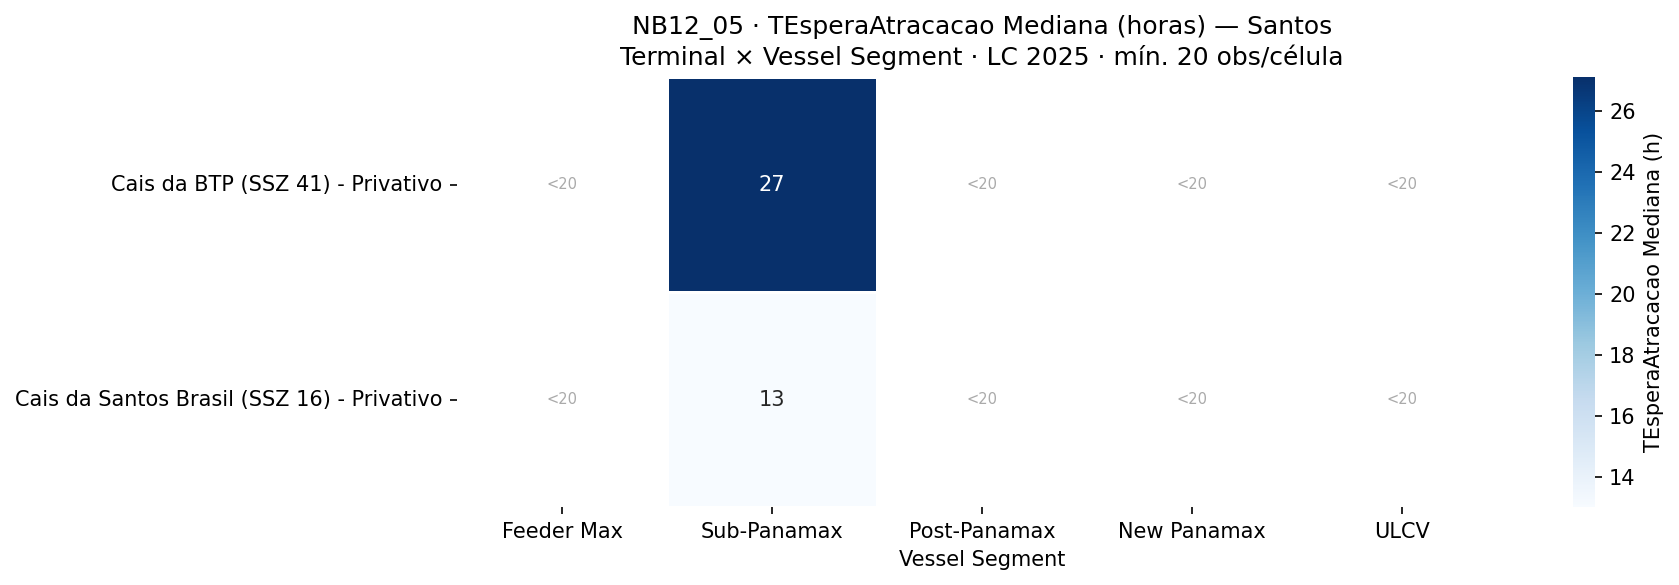

Salvo: nb12_05_heatmap_santos_espera_segment.png


In [18]:
# ── Figura nb12_05: TEsperaAtracacao em Santos por terminal × segment ──────
espera_cols_short = [SEG_SHORT[s] for s in SEGMENT_ORDER]
heat_espera = santos_table.set_index('Terminal')[[f'TEspera_{s}' for s in espera_cols_short]].copy()
heat_espera.columns = espera_cols_short

fig, ax = plt.subplots(figsize=(12, max(4, len(santos_terminais_50) * 0.55)))
mask_e = heat_espera.isna()

sns.heatmap(
    heat_espera, annot=True, fmt='.0f', cmap='Blues',
    mask=mask_e, linewidths=0.5, linecolor='white',
    ax=ax, cbar_kws={'label': 'TEsperaAtracacao Mediana (h)'}
)
for row_idx in range(len(heat_espera)):
    for col_idx in range(len(heat_espera.columns)):
        if mask_e.iloc[row_idx, col_idx]:
            ax.text(col_idx + 0.5, row_idx + 0.5, '<20',
                    ha='center', va='center', fontsize=7, color='#aaaaaa')

ax.set_title('NB12_05 · TEsperaAtracacao Mediana (horas) — Santos\nTerminal × Vessel Segment · LC 2025 · mín. 20 obs/célula',
             fontsize=12)
ax.set_xlabel('Vessel Segment', fontsize=10)
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(FIG_DIR + 'nb12_05_heatmap_santos_espera_segment.png', dpi=150)
plt.show()
print('Salvo: nb12_05_heatmap_santos_espera_segment.png')

---
## Parte 4 — Efeito CMA CGM no Feeder Max

In [19]:
# ── Feeder Max: com e sem CMA CGM ─────────────────────────────────────────
feeder = df_seg[df_seg['vessel_segment'] == 'Feeder Max (1k-3k TEU)'].copy()

feeder_all   = feeder['TEstadia']
feeder_nocma = feeder[feeder['SHIPPING LINE'] != 'CMA CGM']['TEstadia']
feeder_cma   = feeder[feeder['SHIPPING LINE'] == 'CMA CGM']['TEstadia']

cma_share = (feeder['SHIPPING LINE'] == 'CMA CGM').mean() * 100

result_cma = pd.DataFrame({
    'Grupo': ['Feeder Max (todas as carriers)', 'Feeder Max — sem CMA CGM', 'CMA CGM apenas'],
    'N': [len(feeder_all), len(feeder_nocma), len(feeder_cma)],
    'TEstadia_P25':  [feeder_all.quantile(0.25), feeder_nocma.quantile(0.25), feeder_cma.quantile(0.25)],
    'TEstadia_Med':  [feeder_all.median(), feeder_nocma.median(), feeder_cma.median()],
    'TEstadia_P75':  [feeder_all.quantile(0.75), feeder_nocma.quantile(0.75), feeder_cma.quantile(0.75)],
})

delta = feeder_all.median() - feeder_nocma.median()

print(f'CMA CGM share no Feeder Max: {cma_share:.1f}%')
print()
print('TEstadia Feeder Max — efeito CMA CGM:')
print(result_cma.round(1).to_string(index=False))
print()
print(f'Delta mediana (todas vs sem CMA CGM): {delta:+.1f}h')
if delta > 2:
    print('  → CMA CGM eleva a mediana do segmento.')
elif delta < -2:
    print('  → CMA CGM reduz a mediana do segmento.')
else:
    print('  → Efeito CMA CGM marginal na mediana do segmento (<2h).')

CMA CGM share no Feeder Max: 68.5%

TEstadia Feeder Max — efeito CMA CGM:
                         Grupo  N  TEstadia_P25  TEstadia_Med  TEstadia_P75
Feeder Max (todas as carriers) 92          42.6          85.7         152.0
      Feeder Max — sem CMA CGM 29          54.4         104.0         183.4
                CMA CGM apenas 63          40.0          75.4         134.3

Delta mediana (todas vs sem CMA CGM): -18.3h
  → CMA CGM reduz a mediana do segmento.


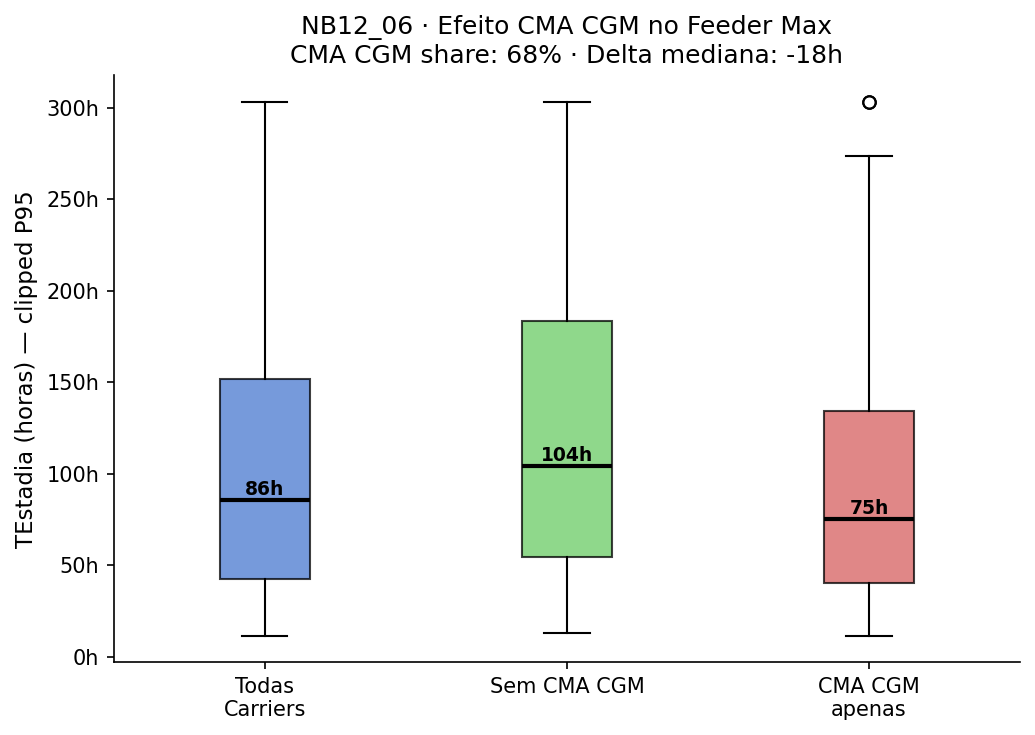

Salvo: nb12_06_feeder_max_cma_cgm.png


In [20]:
# ── Figura nb12_06: Box plot Feeder Max com/sem CMA CGM ───────────────────
p95_feeder = feeder['TEstadia'].quantile(0.95)
feeder_all_clip   = feeder_all.clip(upper=p95_feeder)
feeder_nocma_clip = feeder_nocma.clip(upper=p95_feeder)
feeder_cma_clip   = feeder_cma.clip(upper=p95_feeder)

fig, ax = plt.subplots(figsize=(7, 5))
bp = ax.boxplot(
    [feeder_all_clip.dropna().values, feeder_nocma_clip.dropna().values, feeder_cma_clip.dropna().values],
    labels=['Todas\nCarriers', 'Sem CMA CGM', 'CMA CGM\napenas'],
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2)
)
cores_cma = ['#4878CF', '#6ACC65', '#D65F5F']
for patch, cor in zip(bp['boxes'], cores_cma):
    patch.set_facecolor(cor)
    patch.set_alpha(0.75)

meds_cma = [feeder_all.median(), feeder_nocma.median(), feeder_cma.median()]
for idx, med_v in enumerate(meds_cma):
    ax.text(idx + 1, med_v + 0.5, f'{med_v:.0f}h', ha='center', va='bottom',
            fontsize=9, fontweight='bold')

ax.set_ylabel('TEstadia (horas) — clipped P95', fontsize=11)
ax.set_title(f'NB12_06 · Efeito CMA CGM no Feeder Max\n'
             f'CMA CGM share: {cma_share:.0f}% · Delta mediana: {delta:+.0f}h',
             fontsize=12)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0fh'))
plt.tight_layout()
plt.savefig(FIG_DIR + 'nb12_06_feeder_max_cma_cgm.png', dpi=150)
plt.show()
print('Salvo: nb12_06_feeder_max_cma_cgm.png')

---
## Parte 5 — Decomposição TEstadia: Espera vs Operação por Segment

In [21]:
# ── Decompor TEstadia em componentes ─────────────────────────────────────
# TEstadia ≈ TEsperaAtracacao + TEsperaInicioOp + TOperacao + TEsperaDesatracacao
# TAtracado = TEsperaInicioOp + TOperacao + TEsperaDesatracacao (tempo no berço)

decomp_rows = []
for seg in SEGMENT_ORDER:
    sub = df_seg[df_seg['vessel_segment'] == seg].copy()
    if len(sub) < 20:
        continue
    # Usar medianas de cada componente
    t_esp_at  = sub['TEsperaAtracacao'].median()
    t_esp_ini = sub['TEsperaInicioOp'].median()
    t_op      = sub['TOperacao'].median()
    t_esp_des = sub['TEsperaDesatracacao'].median()
    t_est     = sub['TEstadia'].median()
    soma_comp = t_esp_at + t_esp_ini + t_op + t_esp_des

    if t_est > 0:
        decomp_rows.append({
            'Segment': SEG_SHORT[seg],
            'TEstadia_Med': t_est,
            'TEsperaAtracacao_h': t_esp_at,
            'TEsperaInicioOp_h':  t_esp_ini,
            'TOperacao_h':        t_op,
            'TEsperaDesatracacao_h': t_esp_des,
            'Pct_Espera_Atr':   t_esp_at  / t_est * 100,
            'Pct_Espera_Ini':   t_esp_ini / t_est * 100,
            'Pct_Operacao':     t_op      / t_est * 100,
            'Pct_Espera_Des':   t_esp_des / t_est * 100,
            'N': len(sub),
        })

decomp = pd.DataFrame(decomp_rows)
print('Decomposição TEstadia por Segment (medianas):')
cols_show = ['Segment', 'TEstadia_Med',
             'TEsperaAtracacao_h', 'TOperacao_h',
             'Pct_Espera_Atr', 'Pct_Operacao', 'N']
print(decomp[cols_show].round(1).to_string(index=False))

Decomposição TEstadia por Segment (medianas):
     Segment  TEstadia_Med  TEsperaAtracacao_h  TOperacao_h  Pct_Espera_Atr  Pct_Operacao   N
  Feeder Max          85.7                 4.5         38.1             5.2          44.4  92
 Sub-Panamax          45.4                11.0         19.0            24.1          41.8 271
Post-Panamax          37.3                10.3         18.1            27.6          48.5 216
 New Panamax          53.0                17.4         24.5            32.8          46.3 114


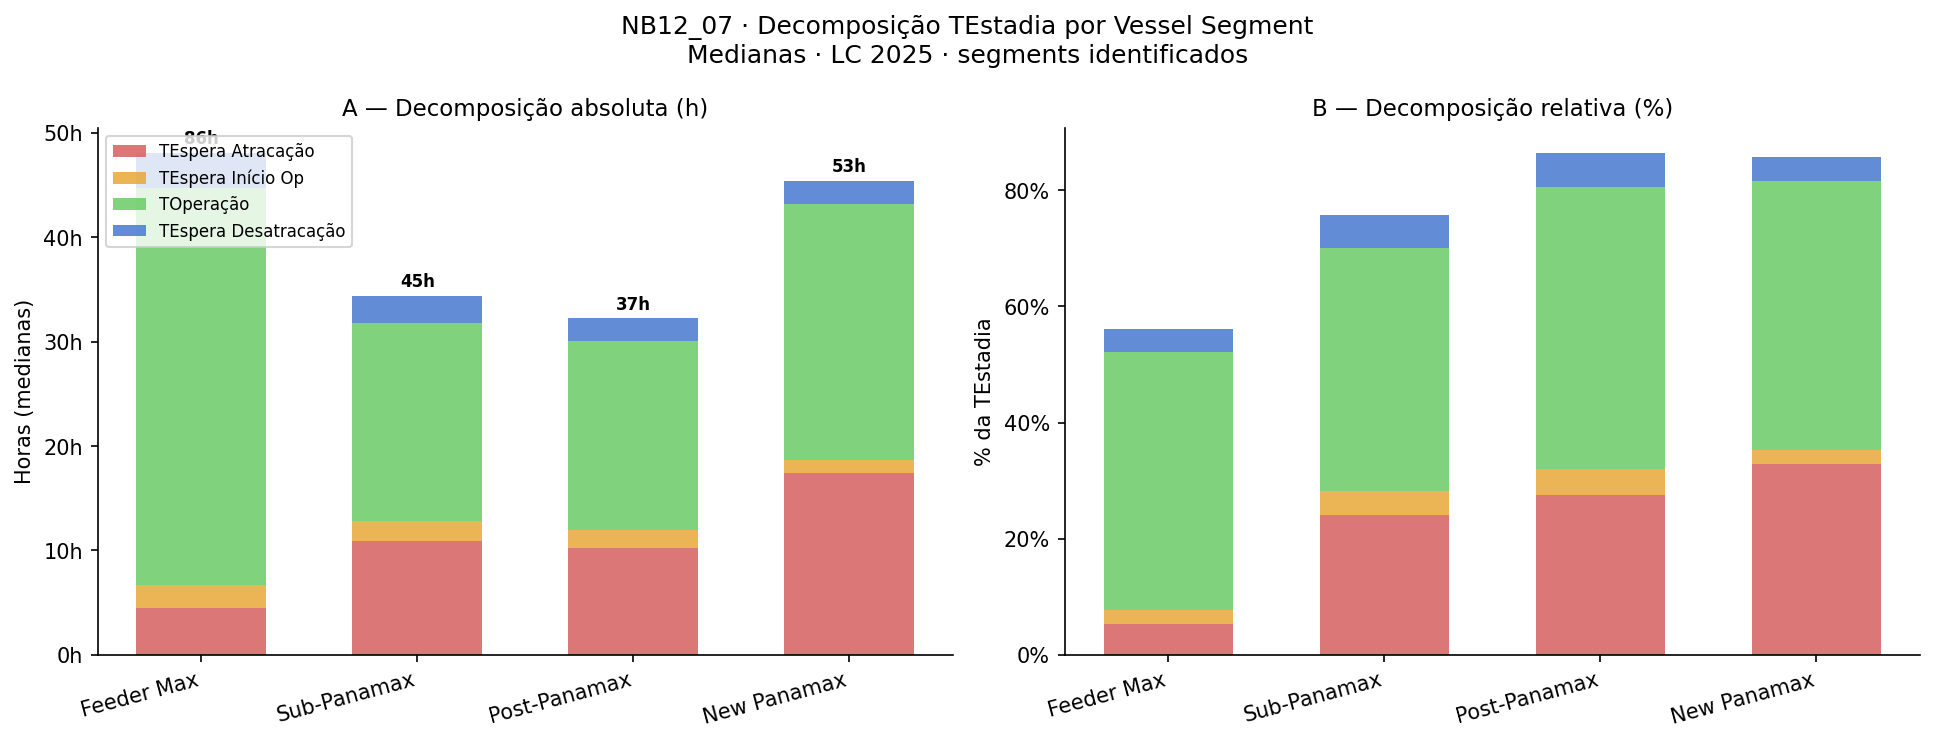

Salvo: nb12_07_decomposicao_testadia_segment.png


In [22]:
# ── Figura nb12_07: Stacked bar decomposição ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Painel A: horas absolutas
ax0 = axes[0]
segs_d  = decomp['Segment'].tolist()
x_d     = np.arange(len(segs_d))
w_d     = 0.6

bot = np.zeros(len(segs_d))
componentes = [
    ('TEsperaAtracacao_h',    'TEspera Atracação',   '#D65F5F'),
    ('TEsperaInicioOp_h',     'TEspera Início Op',   '#E8A838'),
    ('TOperacao_h',           'TOperação',           '#6ACC65'),
    ('TEsperaDesatracacao_h', 'TEspera Desatracação', '#4878CF'),
]
for col_key, label_c, color_c in componentes:
    vals = decomp[col_key].values
    ax0.bar(x_d, vals, w_d, bottom=bot, label=label_c, color=color_c, alpha=0.85)
    bot += vals

ax0.set_xticks(x_d)
ax0.set_xticklabels(segs_d, rotation=15, ha='right')
ax0.set_ylabel('Horas (medianas)', fontsize=10)
ax0.set_title('A — Decomposição absoluta (h)', fontsize=11)
ax0.legend(fontsize=8, loc='upper left')
ax0.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0fh'))
# Anotar TEstadia total
for idx, val in enumerate(decomp['TEstadia_Med']):
    ax0.text(idx, decomp.iloc[idx][['TEsperaAtracacao_h','TEsperaInicioOp_h',
                                    'TOperacao_h','TEsperaDesatracacao_h']].sum() + 0.5,
             f'{val:.0f}h', ha='center', va='bottom', fontsize=8, fontweight='bold')

# Painel B: % relativo
ax1 = axes[1]
bot_pct = np.zeros(len(segs_d))
componentes_pct = [
    ('Pct_Espera_Atr', 'TEspera Atracação',   '#D65F5F'),
    ('Pct_Espera_Ini', 'TEspera Início Op',   '#E8A838'),
    ('Pct_Operacao',   'TOperação',           '#6ACC65'),
    ('Pct_Espera_Des', 'TEspera Desatracação', '#4878CF'),
]
for col_key, label_c, color_c in componentes_pct:
    vals = decomp[col_key].values
    ax1.bar(x_d, vals, w_d, bottom=bot_pct, label=label_c, color=color_c, alpha=0.85)
    bot_pct += vals

ax1.set_xticks(x_d)
ax1.set_xticklabels(segs_d, rotation=15, ha='right')
ax1.set_ylabel('% da TEstadia', fontsize=10)
ax1.set_title('B — Decomposição relativa (%)', fontsize=11)
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

fig.suptitle('NB12_07 · Decomposição TEstadia por Vessel Segment\n'
             'Medianas · LC 2025 · segments identificados', fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR + 'nb12_07_decomposicao_testadia_segment.png', dpi=150)
plt.show()
print('Salvo: nb12_07_decomposicao_testadia_segment.png')

In [23]:
# ── Resposta Parte 5 ───────────────────────────────────────────────────────
print('=== % TEsperaAtracacao / TEstadia por Segment ===')
for _, row in decomp.iterrows():
    print(f"  {row['Segment']:15s}  "
          f"TEstadia={row['TEstadia_Med']:.0f}h  "
          f"%Espera_Atr={row['Pct_Espera_Atr']:.0f}%  "
          f"%Operação={row['Pct_Operacao']:.0f}%  "
          f"N={int(row['N']):,}")

=== % TEsperaAtracacao / TEstadia por Segment ===
  Feeder Max       TEstadia=86h  %Espera_Atr=5%  %Operação=44%  N=92
  Sub-Panamax      TEstadia=45h  %Espera_Atr=24%  %Operação=42%  N=271
  Post-Panamax     TEstadia=37h  %Espera_Atr=28%  %Operação=48%  N=216
  New Panamax      TEstadia=53h  %Espera_Atr=33%  %Operação=46%  N=114


---
## Parte 6 — Outliers P99 (detalhe)

In [24]:
# ── Outliers P99 com vessel_segment ───────────────────────────────────────
# Recriar outliers no dataset final (df)
p99_by_terminal_full = (
    df.groupby('Terminal')['TEstadia']
    .quantile(0.99)
    .reset_index()
    .rename(columns={'TEstadia': 'P99_TEstadia'})
)
df_out = df.merge(p99_by_terminal_full, on='Terminal', how='left')
outliers_full = df_out[df_out['TEstadia'] > df_out['P99_TEstadia']].copy()

print(f'Outliers P99 no dataset LC+Tempos: {len(outliers_full):,} '
      f'({len(outliers_full)/len(df)*100:.2f}%)')
print()
print('Por Terminal (top 10 por TEstadia máxima):')
out_summary = (
    outliers_full.groupby('Terminal')['TEstadia']
    .agg(['count', 'max', 'median'])
    .sort_values('max', ascending=False)
    .rename(columns={'count': 'N_Outliers', 'max': 'TEstadia_Max', 'median': 'TEstadia_Med'})
    .head(10)
)
print(out_summary.round(0).to_string())
print()
print('Nota: valores > P99 por terminal podem ser eventos operacionais reais')
print('(avaria, tempestade, congestionamento extraordinário) — não foram removidos.')

Outliers P99 no dataset LC+Tempos: 318 (1.40%)

Por Terminal (top 10 por TEstadia máxima):
                                                              N_Outliers  TEstadia_Max  TEstadia_Med
Terminal                                                                                            
Corredor de Fertilizantes                                              2        1827.0        1775.0
Corredor de Exportação Leste                                           4        1653.0        1537.0
Terminal de Praia Mole                                                 2        1536.0        1477.0
CAIS PÚBLICO                                                           7        1530.0        1102.0
PIER DA FOSPAR                                                         1        1415.0        1415.0
Terminal Integrador Portuário Luiz Antonio Mesquita - TIPLAM           4        1176.0        1139.0
Corredor de Exportação Oeste                                           1        1113.0        1113.0


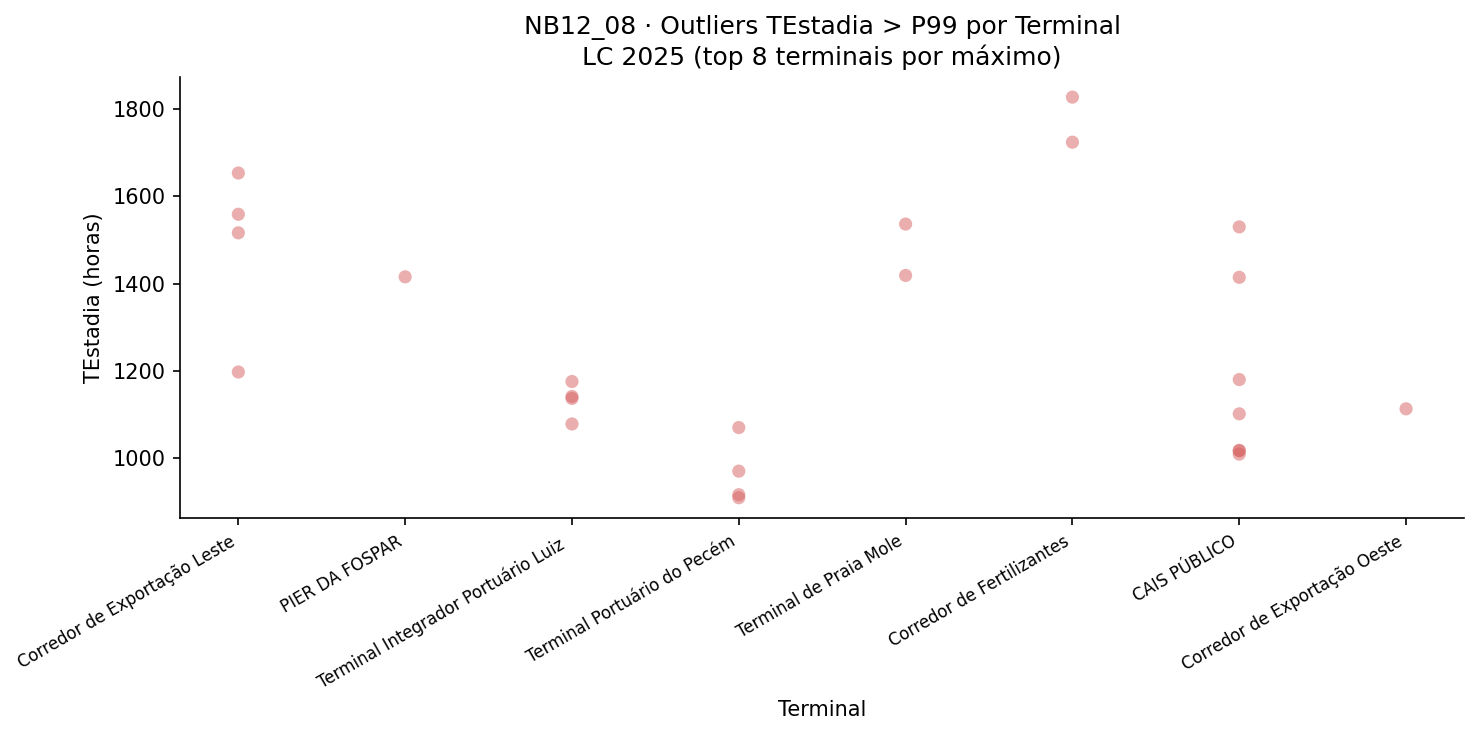

Salvo: nb12_08_outliers_p99_terminal.png


In [25]:
# ── Figura nb12_08: Outliers — TEstadia > P99 por terminal ────────────────
fig, ax = plt.subplots(figsize=(10, 5))
top_out_terms = out_summary.head(8).index.tolist()
out_top = outliers_full[outliers_full['Terminal'].isin(top_out_terms)]

# Shorten terminal names
out_top = out_top.copy()
out_top['Term_Short'] = out_top['Terminal'].str[:35]

ax.scatter(
    out_top['Term_Short'],
    out_top['TEstadia'],
    c='#D65F5F', alpha=0.5, s=40, edgecolors='none'
)
ax.set_xlabel('Terminal', fontsize=10)
ax.set_ylabel('TEstadia (horas)', fontsize=10)
ax.set_title('NB12_08 · Outliers TEstadia > P99 por Terminal\nLC 2025 (top 8 terminais por máximo)',
             fontsize=12)
plt.xticks(rotation=30, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR + 'nb12_08_outliers_p99_terminal.png', dpi=150)
plt.show()
print('Salvo: nb12_08_outliers_p99_terminal.png')

---
## Parte 7 — Exportação CSV

In [26]:
# ── 7.1 KPIs por segment ──────────────────────────────────────────────────
kpi_seg.to_csv(CSV_DIR + 'kpi_vessel_segment_2025.csv', index=False, encoding='utf-8-sig')
print('Salvo: kpi_vessel_segment_2025.csv')

# ── 7.2 Heatmap porto × segment ───────────────────────────────────────────
pivot.reset_index().to_csv(CSV_DIR + 'heatmap_porto_segment_2025.csv', index=False, encoding='utf-8-sig')
print('Salvo: heatmap_porto_segment_2025.csv')

# ── 7.3 Santos por terminal × segment ────────────────────────────────────
santos_table.to_csv(CSV_DIR + 'santos_terminal_segment_2025.csv', index=False, encoding='utf-8-sig')
print('Salvo: santos_terminal_segment_2025.csv')

# ── 7.4 Efeito CMA CGM no Feeder Max ─────────────────────────────────────
result_cma.to_csv(CSV_DIR + 'feeder_max_cma_cgm_2025.csv', index=False, encoding='utf-8-sig')
print('Salvo: feeder_max_cma_cgm_2025.csv')

# ── 7.5 Decomposição por segment ──────────────────────────────────────────
decomp.to_csv(CSV_DIR + 'decomposicao_testadia_segment_2025.csv', index=False, encoding='utf-8-sig')
print('Salvo: decomposicao_testadia_segment_2025.csv')

print('\nExportação concluída.')

Salvo: kpi_vessel_segment_2025.csv
Salvo: heatmap_porto_segment_2025.csv
Salvo: santos_terminal_segment_2025.csv
Salvo: feeder_max_cma_cgm_2025.csv
Salvo: decomposicao_testadia_segment_2025.csv

Exportação concluída.


---
## Limitações Metodológicas

1. **Cobertura do join IMO:** apenas ~2% das atracações LC têm vessel_segment identificado via Vessels_Master_Enriched  
   (dataset limita-se a 8 carriers container). Todas as análises acima aplicam-se exclusivamente a esse subconjunto identificado.

2. **TEstadia é multifatorial:** reflecte porto + terminal + carrier + segmento + sazonalidade. Não é possível isolar o efeito puro do tamanho do navio sem modelos de regressão controlando os outros factores.

3. **Outliers P99:** identificados e reportados (Parte 6), mas não removidos do dataset. Podem representar eventos operacionais reais (avaria, tempestade, congestionamento extraordinário).

4. **Células < 20 obs:** excluídas dos heatmaps e não incluídas em conclusões principais. Listadas separadamente.

5. **CMA CGM / Feeder Max:** a elevada concentração de CMA CGM nesse segmento torna difícil separar efeito do carrier do efeito do tamanho do navio nos resultados do Feeder Max.